### 이전 실습에서 만들어진 모델로 이진 분류 예측하기

In [ ]:
# 새로운 이미지도 크기 조정(150, 150) + 스케일링
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

MODEL_PAHT = 'catdog_best.keras'
# 학습에 사용한 크기와 동일하게 만들어줘야함
IMG_HEIGHT, IMG_WIDTH = 150, 150
THRESH = 0.5 # Sigmoid 임계값 - 조정가능 (0.4 ~ 0.6)

idx_to_name={0:'cats', 1:'dogs'} # JSON으로 읽어올 수 있는 형태

# model
model = tf.keras.models.load_model(MODEL_PAHT)
print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,924,325 (121.78 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,282,884 (81.19 MB)

None


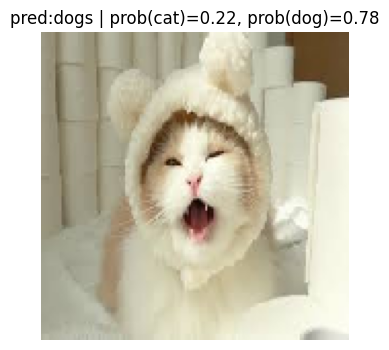

{'path': 'myimage.jpeg', 'pred': 'dogs', 'p_dog': 0.7845651507377625, 'p_cat': 0.21543484926223755}


In [ ]:
# 전처리 함수 생성하기
def predprecess_imageFunc(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    arr = tf.keras.utils.img_to_array(img)  # array형태로 변환
    arr = arr / 255.0                       # 스케일링
    arr = np.expand_dims(arr, axis=0)       # batch 차원 추가 -> (1, H, W , C)
    return arr


# 단일 이미지 예측함수 생성하기
def predict_oneFunc(image_path, show=True):
  x = predprecess_imageFunc(image_path)
  # print(x)

  prob_dog = float(model.predict(x, verbose=0)[0][0])# 시그모이드 출력 dog확률값
  pred_idx = (int(prob_dog >= THRESH))
  pred_name = idx_to_name[pred_idx] # index를 클래스명으로 변경
  prob_cat = 1.0 - prob_dog #  cat 확률값

  # 시각화
  if show:
    img_disp = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    plt.figure(figsize=(4,4))
    plt.imshow(img_disp)
    plt.axis('off')
    plt.title(f'pred:{pred_name} | prob(cat)={prob_cat:.2f}, prob(dog)={prob_dog:.2f}')
    plt.show()

  return {'path':image_path, 'pred':pred_name, 'p_dog':prob_dog, 'p_cat':prob_cat}

res = predict_oneFunc('myimage.jpeg', show=True)
print(res)